# Clustering Analysis
1. K-Means & PCA
2. K Nearest Neighbors

## Import Libraries

In [1]:
# Import necessary libraries for data analysis and visualization
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

## Read Data

In [2]:
df_library = pd.read_csv('data/music_library.csv')
df_library.head()

,#,Song,Artist,BPM,Camelot,Energy,Added At,Duration,Popularity,Genres,...,Valence,Speech,Live,Loud (Db),Key,Time Signature,Spotify Track Id,ISRC,Playlist,album_year
0,1,When the Love is Gone,Des Rocs,141,9A,81,2026-03-05,03:20,52,NaN,...,47,0,20,-4,E Minor,4,5iRv1aH4eNai45KfhjtJ6n,USFYZ2557602,Rock,2026
1,2,BURNER PHONE,cleopatrick,136,9A,91,2026-03-05,03:21,42,NaN,...,46,0,30,-5,E Minor,4,1nUC2uuKUl49tDwQ1m4A1J,CAJXF2500023,Rock,2025
2,3,Queen Of Spades,Styx,135,12A,45,2026-03-05,05:41,36,"classic rock, aor, progressive rock",...,12,0,10,-13,C♯/D♭ Minor,4,54g63GAn77x9NcjiLzy7cW,USAM17802305,Rock,1978
3,4,Go Your Own Way,Fleetwood Mac,136,7B,81,2026-03-05,03:38,62,"yacht rock, classic rock, soft rock",...,82,0,10,-12,F Major,4,15rjQH7nTcTomKwfVMd4xl,USWB19900181,Rock,1988
4,5,I Don't Care Anymore - 2016 Remaster,Phil Collins,140,1B,42,2026-03-05,05:05,61,soft rock,...,44,0,0,-8,B Major,4,24IdPCimVnJJDRuB5YSDiS,USRH11509311,Rock,1982


## Analysis

### 1. K-means & PCA

In [3]:
def cluster_playlist(df_library, playlist_name, features):
    
    def get_best_k(X_scaled, k_range=(3, 11)):
        scores = {}
        for k in range(k_range[0], k_range[1]):
            km = KMeans(n_clusters=k, n_init=50, random_state=42)
            labels = km.fit_predict(X_scaled)
            scores[k] = silhouette_score(X_scaled, labels)
        best_k = max(scores, key=scores.get)
        return best_k, scores
    
    def interpret_loadings(loadings, threshold=0.3):
        """Return dict of PC interpretations based on top-loading features"""
        interpretations = {}
        for pc in loadings.columns:
            sorted_loadings = loadings[pc].reindex(
                loadings[pc].abs().sort_values(ascending=False).index
            )
            top_features = []
            for feature, val in sorted_loadings.items():
                if abs(val) >= threshold:
                    direction = "+" if val > 0 else "-"
                    top_features.append(f"{direction}{feature} ({val:.2f})")
            interpretations[pc] = top_features
        return interpretations
    
    def describe_clusters(centroids_pca, pc_interpretations):
        """Generate plain-language cluster descriptions from centroid positions"""
        descriptions = {}
        pc_names = list(pc_interpretations.keys())
        
        for i, centroid in enumerate(centroids_pca):
            traits = []
            for j, pc in enumerate(pc_names):
                if abs(centroid[j]) > 0.5:  # only mention if meaningfully off-center
                    direction = "high" if centroid[j] > 0 else "low"
                    traits.append(f"{direction} {pc}")
            descriptions[f"Cluster {i}"] = {
                'position': {pc: round(centroid[j], 2) for j, pc in enumerate(pc_names)},
                'traits': traits if traits else ['near center']
            }
        return descriptions
    
    # Filter for playlist
    df_playlist = df_library[df_library['Playlist'] == playlist_name].copy()
    
    # Correlation analysis
    correlation = df_playlist[features].corr()
    
    # Scale features
    X = df_playlist[features].dropna()
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Find best k
    best_k, scores = get_best_k(X_scaled)
    
    # Run clustering
    kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(X_scaled)
    
    # PCA
    pca = PCA(n_components=3)
    X_pca = pca.fit_transform(X_scaled)
    
    # Loadings
    loadings = pd.DataFrame(
        pca.components_.T,
        columns=['PC1', 'PC2', 'PC3'],
        index=features
    )
    
    # Interpretations
    pc_interpretations = interpret_loadings(loadings)
    
    # Transform cluster centroids to PCA space
    centroids_pca = pca.transform(kmeans.cluster_centers_)
    cluster_descriptions = describe_clusters(centroids_pca, pc_interpretations)
    
    # Add cluster labels back to filtered df
    df_playlist = df_playlist.loc[X.index].copy()
    df_playlist['cluster'] = clusters
    
    # === PLOTS ===
    
    # 1. Loadings heatmap
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    sns.heatmap(loadings, annot=True, cmap='RdBu_r', center=0, fmt='.2f', ax=axes[0])
    axes[0].set_title('PCA Loadings')
    
    # 2. Explained variance
    var_explained = pca.explained_variance_ratio_
    cumulative = var_explained.cumsum()
    x_pos = range(1, 4)
    axes[1].bar(x_pos, var_explained, alpha=0.7, label='Individual')
    axes[1].plot(x_pos, cumulative, 'ro-', label='Cumulative')
    axes[1].set_xticks(x_pos)
    axes[1].set_xticklabels(['PC1', 'PC2', 'PC3'])
    axes[1].set_ylabel('Variance Explained')
    axes[1].set_title('PCA Variance')
    axes[1].legend()
    axes[1].set_ylim(0, 1)
    
    plt.tight_layout()
    plt.show()
    
    # 3. Pairwise PCA plots
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    pairs = [(0, 1), (0, 2), (1, 2)]
    labels = ['PC1', 'PC2', 'PC3']
    
    for ax, (i, j) in zip(axes, pairs):
        scatter = ax.scatter(X_pca[:, i], X_pca[:, j], c=clusters, cmap='viridis', alpha=0.7)
        ax.set_xlabel(f'{labels[i]} ({var_explained[i]:.1%})')
        ax.set_ylabel(f'{labels[j]} ({var_explained[j]:.1%})')
        
        # Plot centroids
        ax.scatter(centroids_pca[:, i], centroids_pca[:, j], 
                   c='red', marker='X', s=200, edgecolors='white', linewidths=2)
    
    plt.suptitle(f'{playlist_name} Clusters (k={best_k})', fontsize=14)
    plt.tight_layout()
    plt.show()
    
    # 4. Print interpretations
    print("\n" + "="*50)
    print("PC INTERPRETATIONS")
    print("="*50)
    for pc, features_list in pc_interpretations.items():
        print(f"\n{pc}: {', '.join(features_list)}")
    
    print("\n" + "="*50)
    print("CLUSTER DESCRIPTIONS")
    print("="*50)
    for cluster, info in cluster_descriptions.items():
        print(f"\n{cluster}:")
        print(f"  Position: {info['position']}")
        print(f"  Traits: {', '.join(info['traits'])}")
    
    return {
        'correlation': correlation,
        'best_k': best_k,
        'silhouette_scores': scores,
        'n_songs': len(X),
        'clusters': clusters,
        'kmeans': kmeans,
        'pca': pca,
        'pca_loadings': loadings,
        'pc_interpretations': pc_interpretations,
        'cluster_descriptions': cluster_descriptions,
        'df_clustered': df_playlist
    }

In [4]:
# Create a dictionary to store the results for each playlist
playlist_dict = {name: group for name, group in df_library.groupby('Playlist')}
playlist_dict.keys()

dict_keys(['Alternative', 'Pop', 'Rap-R&B', 'Rock'])

In [5]:
# Set features to use for clustering
FEATURES = ['BPM', 'Valence', 'Dance', 'Energy', 'Acoustic']

Analyzing Alternative playlist...


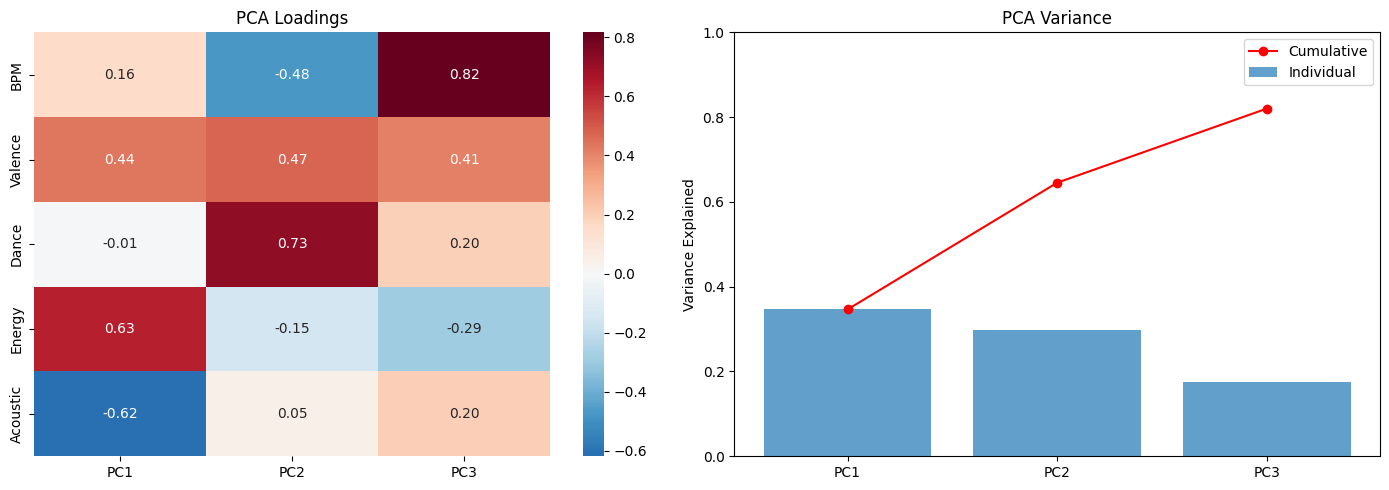

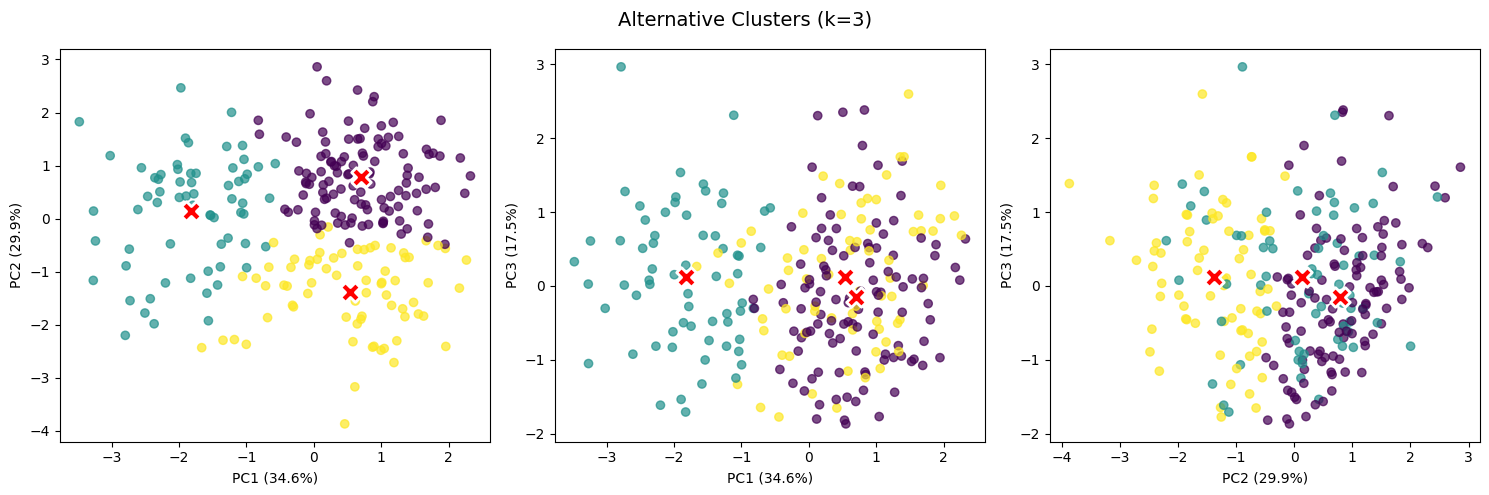


PC INTERPRETATIONS

PC1: +Energy (0.63), -Acoustic (-0.62), +Valence (0.44)

PC2: +Dance (0.73), -BPM (-0.48), +Valence (0.47)

PC3: +BPM (0.82), +Valence (0.41)

CLUSTER DESCRIPTIONS

Cluster 0:
  Position: {'PC1': np.float64(0.7), 'PC2': np.float64(0.78), 'PC3': np.float64(-0.14)}
  Traits: high PC1, high PC2

Cluster 1:
  Position: {'PC1': np.float64(-1.83), 'PC2': np.float64(0.14), 'PC3': np.float64(0.12)}
  Traits: low PC1

Cluster 2:
  Position: {'PC1': np.float64(0.54), 'PC2': np.float64(-1.38), 'PC3': np.float64(0.12)}
  Traits: high PC1, low PC2
Best k for Alternative: 3
Silhouette scores: {3: 0.24123096857732268, 4: 0.22565565528874254, 5: 0.21836129489781475, 6: 0.2251358547532789, 7: 0.20388284520901628, 8: 0.2022800067163884, 9: 0.20088767371094216, 10: 0.20066782157804913}
Correlation matrix:
               BPM   Valence     Dance    Energy  Acoustic
BPM       1.000000  0.000282 -0.302211  0.079385 -0.101565
Valence   0.000282  1.000000  0.393504  0.281869 -0.236186
Danc

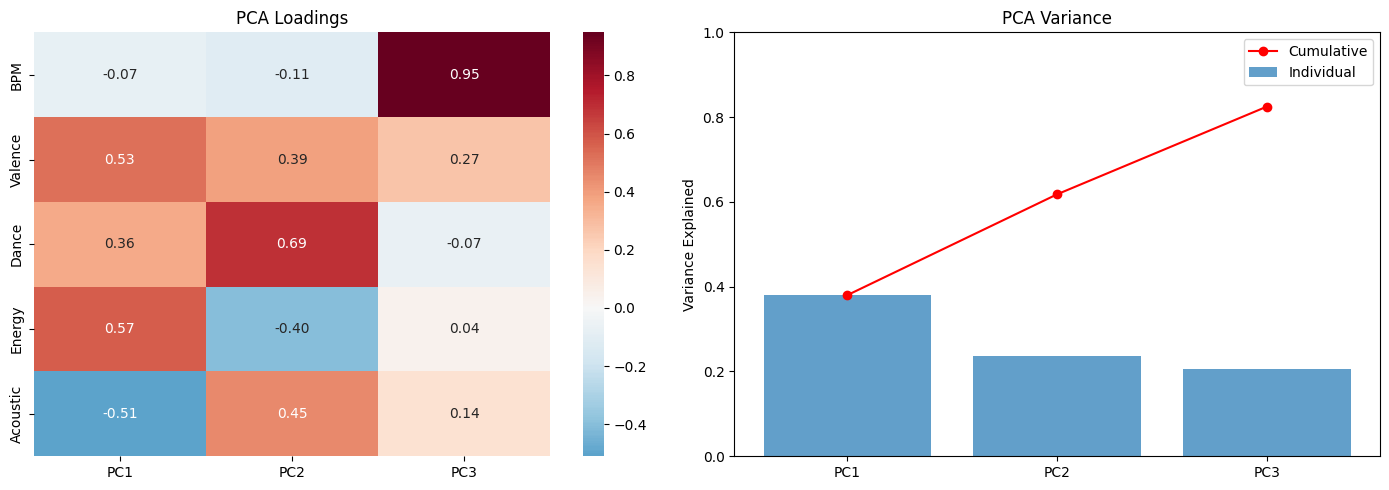

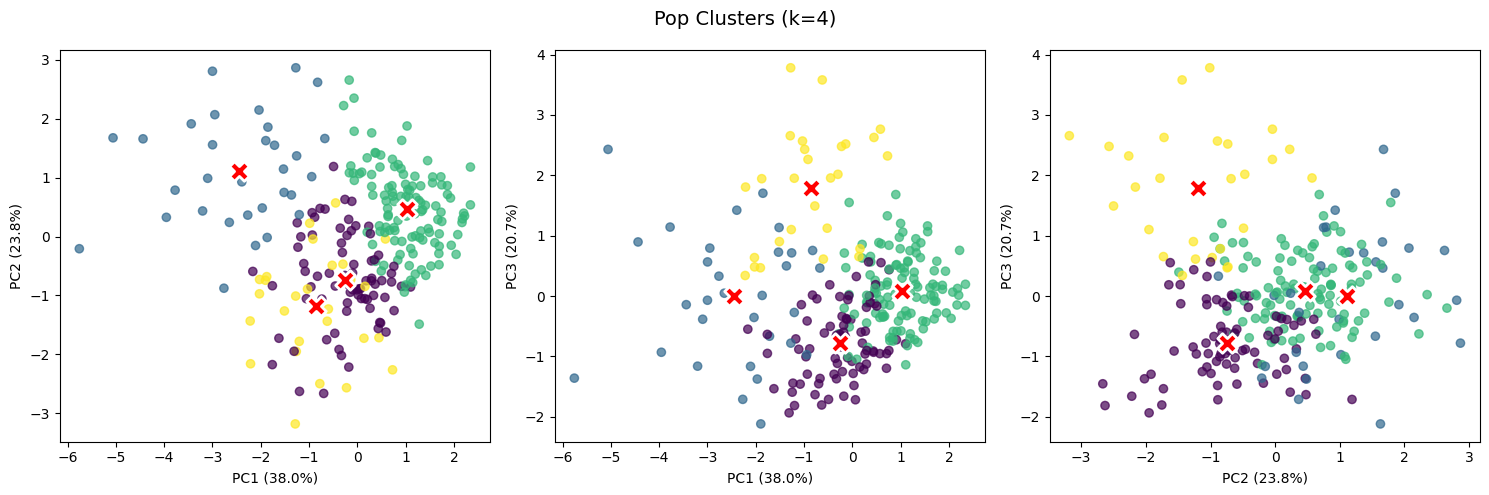


PC INTERPRETATIONS

PC1: +Energy (0.57), +Valence (0.53), -Acoustic (-0.51), +Dance (0.36)

PC2: +Dance (0.69), +Acoustic (0.45), -Energy (-0.40), +Valence (0.39)

PC3: +BPM (0.95)

CLUSTER DESCRIPTIONS

Cluster 0:
  Position: {'PC1': np.float64(-0.25), 'PC2': np.float64(-0.74), 'PC3': np.float64(-0.78)}
  Traits: low PC2, low PC3

Cluster 1:
  Position: {'PC1': np.float64(-2.44), 'PC2': np.float64(1.12), 'PC3': np.float64(0.01)}
  Traits: low PC1, high PC2

Cluster 2:
  Position: {'PC1': np.float64(1.02), 'PC2': np.float64(0.46), 'PC3': np.float64(0.09)}
  Traits: high PC1

Cluster 3:
  Position: {'PC1': np.float64(-0.86), 'PC2': np.float64(-1.19), 'PC3': np.float64(1.79)}
  Traits: low PC1, low PC2, high PC3
Best k for Pop: 4
Silhouette scores: {3: 0.2465155964234077, 4: 0.24831492830002713, 5: 0.23399964041826457, 6: 0.21818048510283217, 7: 0.22372640438231045, 8: 0.20675504633866457, 9: 0.20705233344947024, 10: 0.20524206497900788}
Correlation matrix:
               BPM   Valence 

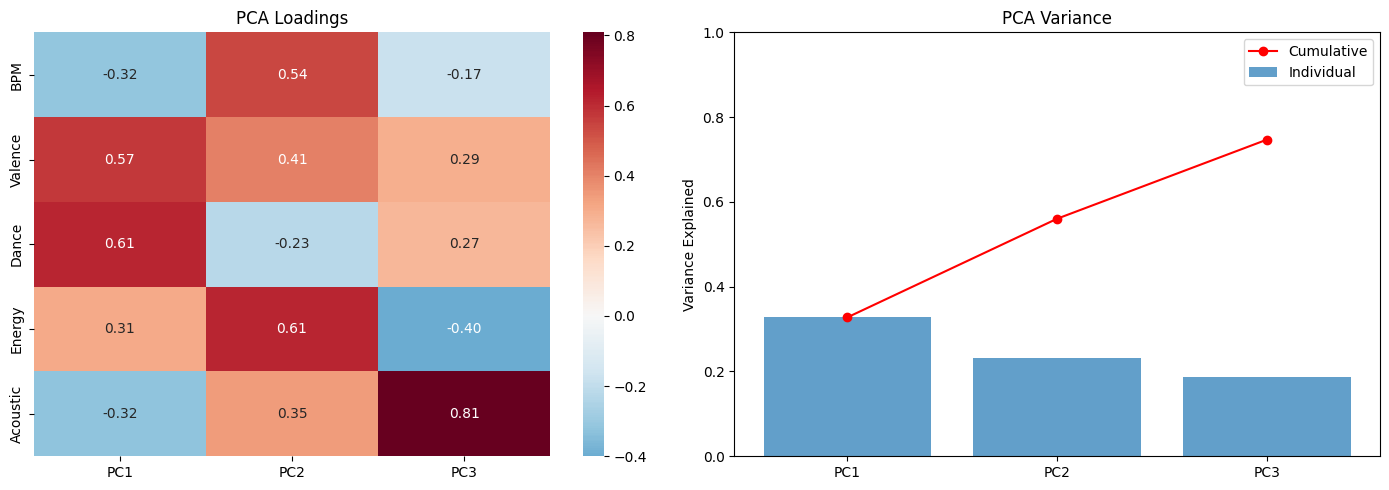

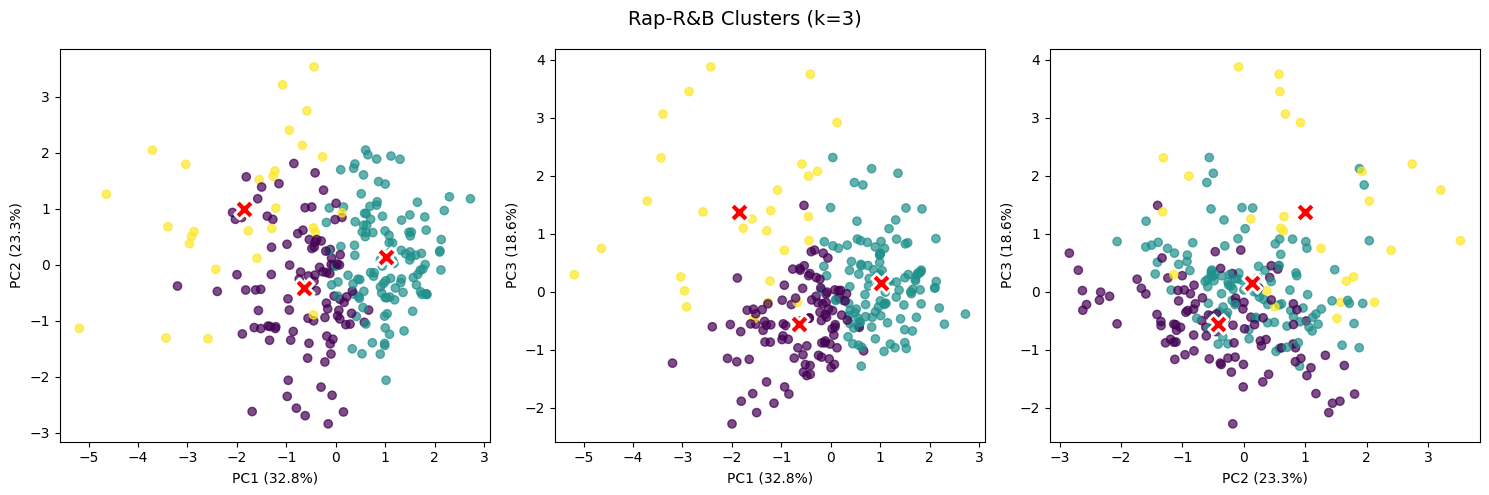


PC INTERPRETATIONS

PC1: +Dance (0.61), +Valence (0.57), -Acoustic (-0.32), -BPM (-0.32), +Energy (0.31)

PC2: +Energy (0.61), +BPM (0.54), +Valence (0.41), +Acoustic (0.35)

PC3: +Acoustic (0.81), -Energy (-0.40)

CLUSTER DESCRIPTIONS

Cluster 0:
  Position: {'PC1': np.float64(-0.65), 'PC2': np.float64(-0.42), 'PC3': np.float64(-0.55)}
  Traits: low PC1, low PC3

Cluster 1:
  Position: {'PC1': np.float64(1.0), 'PC2': np.float64(0.13), 'PC3': np.float64(0.15)}
  Traits: high PC1

Cluster 2:
  Position: {'PC1': np.float64(-1.87), 'PC2': np.float64(0.99), 'PC3': np.float64(1.37)}
  Traits: low PC1, high PC2, high PC3
Best k for Rap-R&B: 3
Silhouette scores: {3: 0.20285984574102947, 4: 0.19500746996741516, 5: 0.18389717209404, 6: 0.19707750340529168, 7: 0.1818659490976211, 8: 0.19049271607569362, 9: 0.18488829120903738, 10: 0.18505535084962307}
Correlation matrix:
               BPM   Valence     Dance    Energy  Acoustic
BPM       1.000000 -0.028442 -0.251272  0.006967  0.111410
Valence

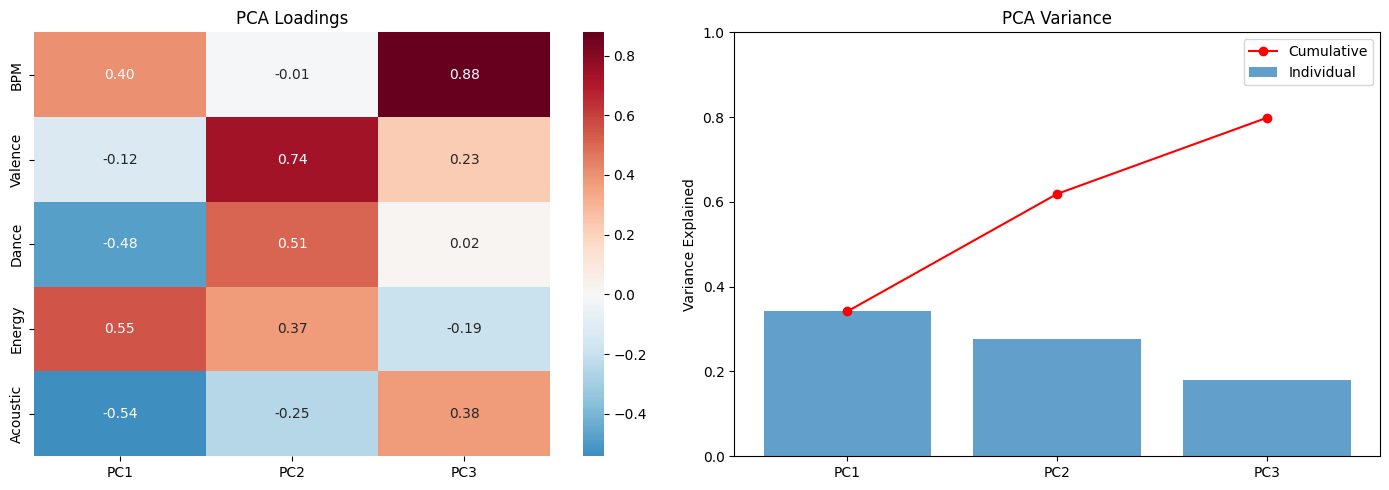

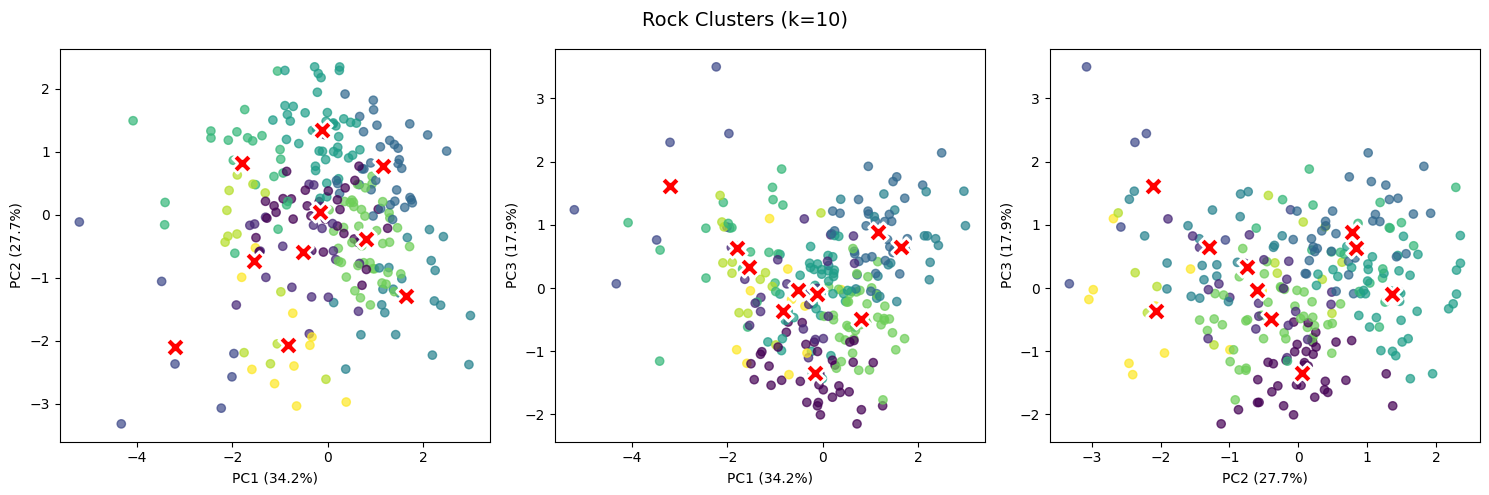


PC INTERPRETATIONS

PC1: +Energy (0.55), -Acoustic (-0.54), -Dance (-0.48), +BPM (0.40)

PC2: +Valence (0.74), +Dance (0.51), +Energy (0.37)

PC3: +BPM (0.88), +Acoustic (0.38)

CLUSTER DESCRIPTIONS

Cluster 0:
  Position: {'PC1': np.float64(-0.16), 'PC2': np.float64(0.05), 'PC3': np.float64(-1.34)}
  Traits: low PC3

Cluster 1:
  Position: {'PC1': np.float64(-0.52), 'PC2': np.float64(-0.6), 'PC3': np.float64(-0.03)}
  Traits: low PC1, low PC2

Cluster 2:
  Position: {'PC1': np.float64(-3.21), 'PC2': np.float64(-2.1), 'PC3': np.float64(1.61)}
  Traits: low PC1, low PC2, high PC3

Cluster 3:
  Position: {'PC1': np.float64(1.17), 'PC2': np.float64(0.77), 'PC3': np.float64(0.89)}
  Traits: high PC1, high PC2, high PC3

Cluster 4:
  Position: {'PC1': np.float64(1.65), 'PC2': np.float64(-1.3), 'PC3': np.float64(0.65)}
  Traits: high PC1, low PC2, high PC3

Cluster 5:
  Position: {'PC1': np.float64(-0.12), 'PC2': np.float64(1.35), 'PC3': np.float64(-0.1)}
  Traits: high PC2

Cluster 6:
  Po

In [6]:
# Analyze each playlist in the library
for playlist, group in playlist_dict.items():
    print(f'Analyzing {playlist} playlist...')
    results = cluster_playlist(df_library, playlist, features=FEATURES)
    group['cluster'] = results['clusters']
    print(f"Best k for {playlist}: {results['best_k']}")
    print(f"Silhouette scores: {results['silhouette_scores']}")
    print(f"Correlation matrix:\n{results['correlation']}\n")
    print(f"Cluster distribution:\n{group['cluster'].value_counts().sort_index()}\n")
    print(f"PCA loadings:\n{results['pca_loadings']}\n")

### 2. K Nearest Neighbors

#### Functions

In [7]:
# Define the feature set once
FEATURES = ['BPM', 'Dance', 'Energy', 'Valence', 'Acoustic']

# 1. Get song features
def get_song_features(df_library, playlist, song_name, artist_name=None):
    df_playlist = df_library[df_library['Playlist'] == playlist]
    
    mask = df_playlist['Song'].str.contains(song_name, case=False, na=False)
    if artist_name:
        mask = mask & df_playlist['Artist'].str.contains(artist_name, case=False, na=False)
    
    if mask.sum() == 0:
        print(f"Couldn't find '{song_name}'" + (f" by '{artist_name}'" if artist_name else ""))
        return None
    
    row = df_playlist[mask].iloc[0]
    
    print(f"{row['Song']} — {row['Artist']}")
    print(f"  BPM: {row['BPM']}, Dance: {row['Dance']}, Energy: {row['Energy']}")
    print(f"  Valence: {row['Valence']}, Acoustic: {row['Acoustic']}")
    
    return [row[f] for f in FEATURES]


# 2. Find similar songs using KNN
def find_similar_songs(df_library, playlist, target, n=5, feature_filters=None):
    """
    Find similar songs using KNN on 5 audio features.
    
    Parameters:
    - target: list of [BPM, Dance, Energy, Valence, Acoustic]
    - feature_filters: dict of feature ranges, e.g. {'Valence': (0.3, 0.7), 'Energy': (0.5, 1.0)}
    """
    df_playlist = df_library[df_library['Playlist'] == playlist].copy()
    
    # Apply any feature filters
    if feature_filters:
        for feature, (low, high) in feature_filters.items():
            df_playlist = df_playlist[
                (df_playlist[feature] >= low) & (df_playlist[feature] <= high)
            ]
    
    if len(df_playlist) < n:
        print(f"Warning: Only {len(df_playlist)} songs match filters, adjusting n")
        n = len(df_playlist)
    
    # Scale features
    X = df_playlist[FEATURES].dropna()
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Fit KNN
    knn = NearestNeighbors(n_neighbors=n, metric='euclidean')
    knn.fit(X_scaled)
    
    # Scale the target point
    target_df = pd.DataFrame([target], columns=FEATURES)
    target_scaled = scaler.transform(target_df)[0]
    
    # Get neighbors
    distances, indices = knn.kneighbors([target_scaled])
    
    # Print header
    print(f"Target: BPM={target[0]}, Dance={target[1]}, Energy={target[2]}, Valence={target[3]}, Acoustic={target[4]}")
    if feature_filters:
        print(f"Filters: {feature_filters}")
    print()
    
    # Print similar songs
    for i, (dist, neighbor_idx) in enumerate(zip(distances[0], indices[0])):
        row = df_playlist.iloc[neighbor_idx]
        print(f"\n{i+1}. {row['Song']} — {row['Artist']}")
        print(f"   BPM: {row['BPM']}, Dance: {row['Dance']}, Energy: {row['Energy']}, Valence: {row['Valence']}, Acoustic: {row['Acoustic']}")
        print(f"   Distance: {dist:.3f}")
    
    # Group summary
    group_df = df_playlist.iloc[indices[0]]
    print(f"\n--- Group summary (n={n}) ---")
    print(f"Mean:  { {f: round(group_df[f].mean(), 2) for f in FEATURES} }")
    print(f"Std:   { {f: round(group_df[f].std(), 2) for f in FEATURES} }")
    
    return group_df

#### Results: Alternative Playlist

##### Step 1: Get songs similar for each seed song

In [8]:
# Seed Song #1: "Dissolve" by Absofacto
target_1 = get_song_features(df_library, 'Alternative', 'Dissolve')

Dissolve — Absofacto,NITESHIFT
  BPM: 85, Dance: 69, Energy: 58
  Valence: 87, Acoustic: 23


In [9]:
# Group 1: Similar to "Dissolve"   
group_1 = find_similar_songs(df_library, playlist='Alternative', target=target_1, n=10)

Target: BPM=85, Dance=69, Energy=58, Valence=87, Acoustic=23


1. Dissolve — Absofacto,NITESHIFT
   BPM: 85, Dance: 69, Energy: 58, Valence: 87, Acoustic: 23
   Distance: 0.000

2. Youth — Glass Animals
   BPM: 96, Dance: 65, Energy: 72, Valence: 79, Acoustic: 13
   Distance: 1.190

3. Doing Good — Milky Chance
   BPM: 98, Dance: 71, Energy: 73, Valence: 73, Acoustic: 29
   Distance: 1.276

4. Devil's Advocate — The Neighbourhood
   BPM: 98, Dance: 66, Energy: 68, Valence: 86, Acoustic: 3
   Distance: 1.277

5. Guillotine — Mansionair,NoMBe
   BPM: 102, Dance: 69, Energy: 65, Valence: 84, Acoustic: 0
   Distance: 1.359

6. Wish I Knew You — The Revivalists
   BPM: 101, Dance: 65, Energy: 72, Valence: 72, Acoustic: 14
   Distance: 1.366

7. home ft. WALK THE MOON — MORGXN,WALK THE MOON
   BPM: 100, Dance: 67, Energy: 71, Valence: 84, Acoustic: 4
   Distance: 1.370

8. It's A Trip! — Joywave
   BPM: 98, Dance: 67, Energy: 72, Valence: 73, Acoustic: 9
   Distance: 1.373

9. Pretty Pimpin 

In [10]:
# Seed Song #2: "Trip Switch" by Nothing But Thieves
target_2  = get_song_features(df_library, playlist='Alternative', song_name='Trip Switch', artist_name='Nothing But Thieves')

Trip Switch — Nothing But Thieves
  BPM: 88, Dance: 65, Energy: 81
  Valence: 77, Acoustic: 2


In [11]:
# Group #2: Similar to "Youth" by Glass Animals
group_2 = find_similar_songs(df_library, playlist='Alternative', target=target_2, n=10)

Target: BPM=88, Dance=65, Energy=81, Valence=77, Acoustic=2


1. Trip Switch — Nothing But Thieves
   BPM: 88, Dance: 65, Energy: 81, Valence: 77, Acoustic: 2
   Distance: 0.000

2. Take My Love and Run — Bad Suns
   BPM: 92, Dance: 66, Energy: 87, Valence: 80, Acoustic: 0
   Distance: 0.448

3. Something to Believe In — Young the Giant
   BPM: 92, Dance: 62, Energy: 89, Valence: 71, Acoustic: 2
   Distance: 0.638

4. Obsession — Joywave
   BPM: 102, Dance: 66, Energy: 84, Valence: 88, Acoustic: 1
   Distance: 0.737

5. Milk & Coffee — NoMBe
   BPM: 91, Dance: 56, Energy: 80, Valence: 71, Acoustic: 0
   Distance: 0.780

6. It's A Trip! — Joywave
   BPM: 98, Dance: 67, Energy: 72, Valence: 73, Acoustic: 9
   Distance: 0.796

7. Electric Bones — Findlay
   BPM: 95, Dance: 59, Energy: 88, Valence: 67, Acoustic: 0
   Distance: 0.834

8. Youth — Glass Animals
   BPM: 96, Dance: 65, Energy: 72, Valence: 79, Acoustic: 13
   Distance: 0.840

9. home ft. WALK THE MOON — MORGXN,WALK THE MOON
   

In [12]:
# Seed Song #3: "Doing Good" by Milky Chance
target_3  = get_song_features(df_library, playlist='Alternative', song_name='Doing Good', artist_name='Milky Chance')   

Doing Good — Milky Chance
  BPM: 98, Dance: 71, Energy: 73
  Valence: 73, Acoustic: 29


In [13]:
# Group #3: Similar to "Doing Good"
group_3 = find_similar_songs(df_library, playlist='Alternative', target=target_3, n=10)

Target: BPM=98, Dance=71, Energy=73, Valence=73, Acoustic=29


1. Doing Good — Milky Chance
   BPM: 98, Dance: 71, Energy: 73, Valence: 73, Acoustic: 29
   Distance: 0.000

2. Don't You Know — Jaymes Young
   BPM: 112, Dance: 75, Energy: 70, Valence: 76, Acoustic: 18
   Distance: 0.839

3. Painting (Masterpiece) — Lewis Del Mar
   BPM: 92, Dance: 73, Energy: 86, Valence: 71, Acoustic: 28
   Distance: 0.876

4. Wish I Knew You — The Revivalists
   BPM: 101, Dance: 65, Energy: 72, Valence: 72, Acoustic: 14
   Distance: 0.880

5. Youth — Glass Animals
   BPM: 96, Dance: 65, Energy: 72, Valence: 79, Acoustic: 13
   Distance: 0.953

6. Last One To Know — Gavin Adcock
   BPM: 102, Dance: 78, Energy: 66, Valence: 58, Acoustic: 30
   Distance: 0.984

7. It's A Trip! — Joywave
   BPM: 98, Dance: 67, Energy: 72, Valence: 73, Acoustic: 9
   Distance: 1.022

8. Pork Soda — Glass Animals
   BPM: 96, Dance: 70, Energy: 66, Valence: 62, Acoustic: 12
   Distance: 1.059

9. Our Song — Rainbow Kitten Su

In [14]:
# Seed Song #4: "Blossom" by Milky Chance
target_4 = get_song_features(df_library, playlist='Alternative', song_name='Blossom', artist_name='Milky Chance')

Blossom — Milky Chance
  BPM: 120, Dance: 75, Energy: 68
  Valence: 85, Acoustic: 3


In [15]:
# Group #4: Similar to "Blossom"
group_4 = find_similar_songs(df_library, playlist='Alternative', target=target_4, n=10)

Target: BPM=120, Dance=75, Energy=68, Valence=85, Acoustic=3


1. Blossom — Milky Chance
   BPM: 120, Dance: 75, Energy: 68, Valence: 85, Acoustic: 3
   Distance: 0.000

2. Typical Ways — Culture Wars
   BPM: 123, Dance: 74, Energy: 67, Valence: 91, Acoustic: 1
   Distance: 0.319

3. Cocoon — Milky Chance
   BPM: 114, Dance: 74, Energy: 66, Valence: 80, Acoustic: 10
   Distance: 0.484

4. Too Sweet — Hozier
   BPM: 117, Dance: 74, Energy: 62, Valence: 93, Acoustic: 3
   Distance: 0.537

5. Put the Gun Down — ZZ Ward
   BPM: 105, Dance: 76, Energy: 72, Valence: 85, Acoustic: 3
   Distance: 0.612

6. Guillotine — Mansionair,NoMBe
   BPM: 102, Dance: 69, Energy: 65, Valence: 84, Acoustic: 0
   Distance: 0.851

7. Don't You Know — Jaymes Young
   BPM: 112, Dance: 75, Energy: 70, Valence: 76, Acoustic: 18
   Distance: 0.887

8. Running From My Shadow (feat. grandson) — Mike Shinoda,grandson
   BPM: 122, Dance: 76, Energy: 72, Valence: 64, Acoustic: 2
   Distance: 0.965

9. home ft. WALK THE

In [16]:
# Seed Song #5: "Body Heat" by Goldie Boutilier
target_5 = get_song_features(df_library, playlist='Alternative', song_name='Body Heat', artist_name='Goldie Boutilier')

Body Heat — Goldie Boutilier
  BPM: 115, Dance: 88, Energy: 53
  Valence: 88, Acoustic: 14


In [17]:
# Group #5: Similar to "Body Heat"
group_5 = find_similar_songs(df_library, playlist='Alternative', target=target_5, n=10)

Target: BPM=115, Dance=88, Energy=53, Valence=88, Acoustic=14


1. Body Heat — Goldie Boutilier
   BPM: 115, Dance: 88, Energy: 53, Valence: 88, Acoustic: 14
   Distance: 0.000

2. Basic Being Basic — Djo
   BPM: 122, Dance: 86, Energy: 59, Valence: 94, Acoustic: 12
   Distance: 0.562

3. thank god — Christian French
   BPM: 136, Dance: 84, Energy: 63, Valence: 79, Acoustic: 7
   Distance: 1.171

4. Dangerous — Big Data,Joywave
   BPM: 103, Dance: 76, Energy: 58, Valence: 96, Acoustic: 1
   Distance: 1.314

5. Damage Done — Kita Alexander
   BPM: 118, Dance: 75, Energy: 48, Valence: 69, Acoustic: 11
   Distance: 1.379

6. Kangaroo Court — Capital Cities
   BPM: 100, Dance: 76, Energy: 58, Valence: 98, Acoustic: 1
   Distance: 1.381

7. Too Sweet — Hozier
   BPM: 117, Dance: 74, Energy: 62, Valence: 93, Acoustic: 3
   Distance: 1.381

8. Cocoon — Milky Chance
   BPM: 114, Dance: 74, Energy: 66, Valence: 80, Acoustic: 10
   Distance: 1.445

9. 3 Nights — Dominic Fike
   BPM: 152, Dance: 

In [18]:
# Seed Song #6: "Cowboy Gangster Politician" by Goldie Boutilier
target_6  = get_song_features(df_library, playlist='Alternative', song_name='Cowboy Gangster Politician', artist_name='Goldie Boutilier')

Cowboy Gangster Politician — Goldie Boutilier
  BPM: 130, Dance: 67, Energy: 70
  Valence: 63, Acoustic: 21


In [19]:
# Group 6: Similar to "Cowboy Gangster Politician"
group_6 = find_similar_songs(df_library, playlist='Alternative', target=target_6, n=10)

Target: BPM=130, Dance=67, Energy=70, Valence=63, Acoustic=21


1. Cowboy Gangster Politician — Goldie Boutilier
   BPM: 130, Dance: 67, Energy: 70, Valence: 63, Acoustic: 21
   Distance: 0.000

2. Brazil — Declan McKenna
   BPM: 121, Dance: 69, Energy: 62, Valence: 67, Acoustic: 9
   Distance: 0.873

3. No Room in Frame — Death Cab for Cutie
   BPM: 125, Dance: 64, Energy: 72, Valence: 44, Acoustic: 20
   Distance: 0.899

4. Deadcrush — alt-J
   BPM: 143, Dance: 65, Energy: 62, Valence: 60, Acoustic: 10
   Distance: 0.902

5. Blood In The Cut — K.Flay
   BPM: 130, Dance: 77, Energy: 66, Valence: 64, Acoustic: 12
   Distance: 0.943

6. Don't You Know — Jaymes Young
   BPM: 112, Dance: 75, Energy: 70, Valence: 76, Acoustic: 18
   Distance: 1.091

7. Used to the Darkness — Des Rocs
   BPM: 106, Dance: 67, Energy: 75, Valence: 47, Acoustic: 18
   Distance: 1.181

8. Loud(y) — Lewis Del Mar
   BPM: 140, Dance: 72, Energy: 59, Valence: 48, Acoustic: 30
   Distance: 1.187

9. broken — lovely

In [37]:
# Seed Song #7: "Capricorn" 
target_7  = get_song_features(df_library, playlist='Alternative', song_name='Capricorn', artist_name='Elderbrook')

Capricorn — Elderbrook
  BPM: 121, Dance: 83, Energy: 85
  Valence: 87, Acoustic: 1


In [38]:
# Group 7: Similar to "Capricorn" by Elderbrook
group_7 = find_similar_songs(df_library, playlist='Alternative', target=target_7, n=10)

Target: BPM=121, Dance=83, Energy=85, Valence=87, Acoustic=1


1. Capricorn — Elderbrook
   BPM: 121, Dance: 83, Energy: 85, Valence: 87, Acoustic: 1
   Distance: 0.000

2. Bad Habit — The Kooks
   BPM: 123, Dance: 73, Energy: 88, Valence: 85, Acoustic: 5
   Distance: 0.849

3. I'm Not Really Here — X Ambassadors
   BPM: 109, Dance: 71, Energy: 83, Valence: 83, Acoustic: 1
   Distance: 1.074

4. Salt — Bad Suns
   BPM: 120, Dance: 71, Energy: 94, Valence: 89, Acoustic: 5
   Distance: 1.134

5. Put the Gun Down — ZZ Ward
   BPM: 105, Dance: 76, Energy: 72, Valence: 85, Acoustic: 3
   Distance: 1.165

6. Blossom — Milky Chance
   BPM: 120, Dance: 75, Energy: 68, Valence: 85, Acoustic: 3
   Distance: 1.262

7. Typical Ways — Culture Wars
   BPM: 123, Dance: 74, Energy: 67, Valence: 91, Acoustic: 1
   Distance: 1.364

8. Social Cues — Cage The Elephant
   BPM: 132, Dance: 67, Energy: 91, Valence: 93, Acoustic: 1
   Distance: 1.414

9. Running From My Shadow (feat. grandson) — Mike Shinoda,

In [40]:
# Seed Song #8: "Fall Over" 
target_8 = get_song_features(df_library, playlist='Alternative', song_name='Fall Over', artist_name='Banks')

Fall Over — BANKS
  BPM: 130, Dance: 65, Energy: 86
  Valence: 63, Acoustic: 1


In [41]:
# Group 8: Similar to "Fall Over" by Banks
group_8 = find_similar_songs(df_library, playlist='Alternative', target=target_8, n=10)

Target: BPM=130, Dance=65, Energy=86, Valence=63, Acoustic=1


1. Fall Over — BANKS
   BPM: 130, Dance: 65, Energy: 86, Valence: 63, Acoustic: 1
   Distance: 0.000

2. Rules — Rafferty
   BPM: 137, Dance: 63, Energy: 86, Valence: 53, Acoustic: 4
   Distance: 0.553

3. Red Hot Lights — Moon Taxi
   BPM: 123, Dance: 60, Energy: 87, Valence: 55, Acoustic: 1
   Distance: 0.593

4. East of Eden — Zella Day
   BPM: 123, Dance: 60, Energy: 79, Valence: 58, Acoustic: 4
   Distance: 0.702

5. Electric Love — BØRNS
   BPM: 120, Dance: 61, Energy: 80, Valence: 52, Acoustic: 1
   Distance: 0.785

6. Trojans — Atlas Genius
   BPM: 140, Dance: 72, Energy: 82, Valence: 54, Acoustic: 1
   Distance: 0.816

7. Red Balloon — Deal Casino
   BPM: 152, Dance: 61, Energy: 85, Valence: 65, Acoustic: 1
   Distance: 0.875

8. Freaks — The Hawk In Paris
   BPM: 133, Dance: 65, Energy: 79, Valence: 82, Acoustic: 0
   Distance: 0.955

9. broken — lovelytheband
   BPM: 123, Dance: 67, Energy: 73, Valence: 51, Acous

##### Step 2: Concat songs, filter, and sort

In [46]:
# Combine all groups into one DataFrame, removing duplicates and sorting by BPM and Dance
knn_combined = (
    pd.concat([group_1, group_2, group_3, group_4, group_5, group_6, group_7, group_8])
    .drop_duplicates(subset=['Song', 'Artist'])
    .sort_values(['BPM', 'Valence', 'Dance'])
    .reset_index(drop=True)
)

# Print summary stats for the combined group
print(f"Combined Group Summary (n={len(knn_combined)}):")
print(f"Mean:   {round(knn_combined[FEATURES].mean(), 2).to_dict()}")
print(f"Std:    {round(knn_combined[FEATURES].std(), 2).to_dict()}")
print(f"Range:  {round(knn_combined[FEATURES].min(), 2).to_dict()} to {round(knn_combined[FEATURES].max(), 2).to_dict()}")

# Get relevant columns for the combined group and valence
knn_combined = knn_combined[['Song', 'Artist', 'BPM', 'Valence', 'Dance', 'Energy', 'Acoustic', 'Popularity', 'album_year']]
knn_combined.to_csv('knn_combined.csv', index=False)
knn_combined

Combined Group Summary (n=57):
Mean:   {'BPM': 113.79, 'Dance': 69.49, 'Energy': 73.09, 'Valence': 73.37, 'Acoustic': 8.04}
Std:    {'BPM': 17.11, 'Dance': 7.36, 'Energy': 11.0, 'Valence': 14.14, 'Acoustic': 8.9}
Range:  {'BPM': 85, 'Dance': 54, 'Energy': 48, 'Valence': 44, 'Acoustic': 0} to {'BPM': 152, 'Dance': 88, 'Energy': 94, 'Valence': 98, 'Acoustic': 30}


,Song,Artist,BPM,Valence,Dance,Energy,Acoustic,Popularity,album_year
0,Dissolve,"Absofacto,NITESHIFT",85,87,69,58,23,57,2024
1,Trip Switch,Nothing But Thieves,88,77,65,81,2,53,2015
2,Milk & Coffee,NoMBe,91,71,56,80,0,51,2018
3,Pretty Pimpin,Kurt Vile,91,76,57,66,9,57,2015
4,Something to Believe In,Young the Giant,92,71,62,89,2,61,2016
5,Painting (Masterpiece),Lewis Del Mar,92,71,73,86,28,46,2016
6,Take My Love and Run,Bad Suns,92,80,66,87,0,41,2014
7,SPIT IN MY FACE!,ThxSoMch,94,65,73,79,5,79,2022
8,Electric Bones,Findlay,95,67,59,88,0,38,2017
9,Our Song,Rainbow Kitten Surprise,96,53,66,71,20,51,2020


In [47]:
knn_combined.describe()

,BPM,Valence,Dance,Energy,Acoustic,Popularity,album_year
count,57.000000,57.000000,57.000000,57.000000,57.000000,57.000000,57.000000
mean,113.789474,73.368421,69.491228,73.087719,8.035088,53.596491,2017.789474
std,17.112795,14.140408,7.358481,10.997209,8.900170,16.883910,3.519014
min,85.000000,44.000000,54.000000,48.000000,0.000000,0.000000,2012.000000
25%,98.000000,63.000000,65.000000,66.000000,1.000000,42.000000,2015.000000
50%,115.000000,76.000000,69.000000,72.000000,4.000000,54.000000,2017.000000
75%,123.000000,85.000000,74.000000,83.000000,12.000000,66.000000,2020.000000
max,152.000000,98.000000,88.000000,94.000000,30.000000,81.000000,2025.000000
